# Compare trained models using Dynamical Similarity Analysis (DSA)

https://arxiv.org/pdf/2306.10168

Code:
https://github.com/mitchellostrow/DSA


### *!! There is bug in their code !!*

You must import as follows (inside poetry shell):
* <code>git clone https://github.com/mitchellostrow/DSA</code>
* Go to DSA/DSA/dsa.py line 327 and remove zero_pad argument from self.simdist.fit_score call
* <code>cd DSA/<br/>pip install -e .</code>

(then for me to see poetry kernel to use vscode ipynb):

<code>python -m ipykernel install --user --name=pirnns-py3.11 --display-name "Python (poetry-pirnns)"</code>

## Step 0: Set up and imports

In [21]:
# autoreload
%load_ext autoreload
%autoreload 2
# jupyter black formatter
%load_ext jupyter_black

import os
import subprocess
import sys


gitroot_path = subprocess.check_output(
    ["git", "rev-parse", "--show-toplevel"], universal_newlines=True
)

os.chdir(os.path.join(gitroot_path[:-1], "pirnns"))
print("Working directory: ", os.getcwd())

sys_dir = os.path.dirname(os.getcwd())
sys.path.append(sys_dir)
print("Directory added to path: ", sys_dir)
sys.path.append(os.getcwd())
print("Directory added to path: ", os.getcwd())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
Working directory:  /home/abby/code/sloppy/pirnns/pirnns
Directory added to path:  /home/abby/code/sloppy/pirnns
Directory added to path:  /home/abby/code/sloppy/pirnns/pirnns


In [22]:
import copy
import glob
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import yaml

from datamodule import PathIntegrationDataModule
from DSA import DMD, DSA, SimilarityTransformDist
from lightning import seed_everything
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

from pirnns.rnns.rnn import RNN, RNNLightning
from pirnns.rnns.coupled_rnn import CoupledRNN, CoupledRNNLightning
from pirnns.rnns.multitimescale_rnn import MultiTimescaleRNN, MultiTimescaleRNNLightning

## Step 1: Load data

We need each RNN to generate trajectories. We then can use the sequence of hidden states to get DMD matrix. Then we compare those matrices for the similarity analysis.

In [8]:
checkpoint_dir = "logs/checkpoints"
for save_name in os.listdir(checkpoint_dir):
    config_files = glob.glob(f"{checkpoint_dir}/{save_name}/config_*.yaml")
    if len(config_files) > 0:
        with open(config_files[0]) as f:
            config = yaml.safe_load(f)
            # just need one config file; data config should be the same for all models
            break

    print(f"No YAML config found in {checkpoint_dir}/{save_name}")

In [9]:
# load data
num_trajectories = 10000
batch_size = 1

eval_datamodule = PathIntegrationDataModule(
    num_trajectories=num_trajectories,
    batch_size=batch_size,
    num_workers=1,
    train_val_split=0.0,
    velocity_representation=config["velocity_representation"],
    dt=config["dt"],
    num_time_steps=config["num_time_steps"],
    arena_size=config["arena_size"],  # Changed from arena_L
    speed_scale=config["speed_scale"],  # Changed from mu_speed
    sigma_speed=config["sigma_speed"],
    tau_vel=config["tau_vel"],
    sigma_rotation=config["sigma_rotation"],
    border_region=config["border_region"],
    num_place_cells=config["num_place_cells"],
    place_cell_rf=config["place_cell_rf"],
    surround_scale=config["surround_scale"],
    DoG=config["DoG"],
    trajectory_type=config["trajectory_type"],
    place_cell_layout=config["place_cell_layout"],
)

eval_datamodule.setup()

eval_loader = eval_datamodule.val_dataloader()

print(f"Number of validation batches: {len(eval_loader)}")
print(f"Validation dataset size: {len(eval_datamodule.val_dataset)}")

Number of validation batches: 10000
Validation dataset size: 10000


### Step 2: Model loading functions

<code>python main.py --config configs/{vanilla|mts}_config.yaml</code>

use <code>multirun: 10</code> in config to run for each 10 seeds!
- single timescale, alpha = 0.1
- single timescale, alpha =0.5 
- single timescale, alpha =1
- 2 timescales, alphas = [0.25, 0.75]
- 4 timescales, alphas= [0.25, 0.5, 0.75, 1]
- power-law, default set up


In [10]:
# Util fns to load model type and model


def get_model_type_from_config(config: dict):
    model_type = config.get("model_type", "vanilla").lower()

    if model_type == "vanilla":
        return f"{model_type}_alpha={config['alpha']}"
    elif model_type == "multitimescale":
        if config["timescales_config"]["type"] == "discrete":
            return f"{model_type}_alphas={config['timescales_config']['values']}"
        elif config["timescales_config"]["type"] == "continuous":
            return (
                f"{model_type}_alpha-dist={config['timescales_config']['distribution']}"
            )
        else:
            print("AH THIS IS ILLEGAL")
    else:
        print("AH THIS IS ILLEGAL")


def load_model_from_checkpoint(config: dict, checkpoint_file):
    model_type = config.get("model_type", "vanilla").lower()

    if model_type == "vanilla":
        model = RNN(
            input_size=config["input_size"],
            hidden_size=config["hidden_size"],
            output_size=config["num_place_cells"],  # Updated parameter name
            alpha=config["alpha"],
            activation=getattr(nn, config["activation"]),
        )

        rnn_lightning = RNNLightning.load_from_checkpoint(
            checkpoint_file,
            model=model,
            learning_rate=config["learning_rate"],
            weight_decay=config["weight_decay"],
            step_size=config["step_size"],
            gamma=config["gamma"],
        )
    elif model_type == "multitimescale":
        model = MultiTimescaleRNN(
            input_size=config["input_size"],
            hidden_size=config["hidden_size"],
            output_size=config["num_place_cells"],
            dt=config["dt"],
            timescales_config=config["timescales_config"],
            activation=getattr(nn, config["activation"]),
        )

        rnn_lightning = MultiTimescaleRNNLightning.load_from_checkpoint(
            checkpoint_file,
            model=model,
            learning_rate=config["learning_rate"],
            weight_decay=config["weight_decay"],
            step_size=config["step_size"],
            gamma=config["gamma"],
        )
    else:
        print("AH THIS IS ILLEGAL")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

    return rnn_lightning.model

## Step 3: Calculate Dynamic Mode Decomposition (DMD)

This bit takes a while. So I save the dmd matrix in each checkpoint file to avoid redundant calculation when I inevitably forget a notebook is running and I shut my computer and the server connection closes.

They have a DSA function, but because we are doing it for 60+ models, this is not feasible time or space wise. Instead, we can go model-by-model to calculate the DMD matrices, which are much smaller, and then we do a Procrustes similarity analysis afterwards (which also takes a bit of time).

The steps done here as follows. For each model:
* load model
* generate output data and hidden state activations
* reduce dimensions of activations (memory constraint; there is precedent)
* fit DMD

Note: we should also do a grid search on DMD parameters (n_delays, rank, delay_interval), but this is fine for now

In [27]:
# Default parameters from example in paper
n_delays = 75
rank = 100  # this will be shape of DMD matrix
delay_interval = 1
pca_red_dim = 10
device = "cuda" if torch.cuda.is_available() else "cpu"
save_dmds = True
force_recalculate_dmds = False

dmd_models, model_types, model_ids = [], [], []
for i, run_name in enumerate(os.listdir(checkpoint_dir)):
    print(f"Loading model #{i}")
    _, run_date, run_id = run_name.split("_")

    run_dir = os.path.join(checkpoint_dir, run_name)

    # Step 1: locate model and model config files
    config_path = f"{run_dir}/config_{run_date}_{run_id}.yaml"
    if not os.path.exists(config_path):
        # means still is training this boy
        continue
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    checkpoint_files = glob.glob(f"{run_dir}/best-model-*.ckpt")
    model_type = get_model_type_from_config(config)

    # Step 2a: see if short cut; dmd is already loaded
    if not force_recalculate_dmds:
        alleged_dmd_filename = f"{run_dir}/dmd.npy"
        alleged_untrained_dmd_filename = f"{run_dir}/untrained_dmd.npy"
        if os.path.exists(alleged_dmd_filename):
            dmd_matrix = np.load(alleged_dmd_filename)

            dmd_models.append(dmd_matrix)
            model_types.append(model_type)
            model_ids.append(run_id)
            print(
                f"Loaded cached dmd matrix for {model_type} model from run: {run_id}! Skipping reinvention of wheel"
            )
            continue

    # Step 2b: create the correct model based on type
    print(f"Loading Lightning checkpoint from: {checkpoint_files[0]}")
    model = load_model_from_checkpoint(config, checkpoint_files[0])
    print(f"Loaded {model_type} model from run: {run_id}")

    # Step 3: run model on input data to get activations
    print("Calculating model activations")
    this_model_activations = []
    for _, (inputs, positions, place_cells) in enumerate(eval_loader):
        inputs = inputs.to(device)
        positions = positions.to(device)
        place_cells = place_cells.to(device)

        hidden_states, outputs = model(
            inputs=inputs, place_cells_0=place_cells[:, 0, :]
        )

        # convert from [1, 20, 4096] to [20, 4096] = (time, features)
        squeezed_hidden_states = hidden_states.squeeze(0)
        this_model_activations.append(squeezed_hidden_states)

    # make shape (batches*batch_size*time_steps, num_neurons) = [200000, 4096]
    this_model_activations = torch.cat(this_model_activations)

    # Step 3b: reduce dimensions of model activations via pca to help with memory :~)
    # god knows if actually legal but they did it

    pca_red_dim = 12  # maybe choose 15

    pca = PCA(n_components=pca_red_dim)
    red_model_activations = pca.fit_transform(
        this_model_activations.cpu().detach().numpy()
    )  # [Txbatch, red_dim]
    print(
        f"Total explained variance over {pca_red_dim} dimensions: {sum(pca.explained_variance_ratio_)}"
    )

    # Step 4: calcualate DMD
    dmd = DMD(
        red_model_activations,
        n_delays=n_delays,
        rank=rank,
        delay_interval=delay_interval,
        device="cuda",
    )
    dmd.fit()

    dmd_matrix = dmd.A_v.cpu().numpy()
    if save_dmds:
        np.save(f"{run_dir}/dmd.npy", dmd_matrix)

    dmd_models.append(dmd_matrix)
    model_types.append(model_type)
    model_ids.append(run_id)

Loading model #0
Loaded cached dmd matrix for multitimescale_alphas=[0.25, 0.5, 0.75, 1] model from run: 014718! Skipping reinvention of wheel
Loading model #1
Loaded cached dmd matrix for vanilla_alpha=0.5 model from run: 232028! Skipping reinvention of wheel
Loading model #2
Loaded cached dmd matrix for vanilla_alpha=1 model from run: 030827! Skipping reinvention of wheel
Loading model #3
Loaded cached dmd matrix for vanilla_alpha=0.1 model from run: 193809! Skipping reinvention of wheel
Loading model #4
Loaded cached dmd matrix for vanilla_alpha=0.5 model from run: 010831! Skipping reinvention of wheel
Loading model #5
Loaded cached dmd matrix for multitimescale_alpha-dist=powerlaw model from run: 143053! Skipping reinvention of wheel
Loading model #6
Loaded cached dmd matrix for vanilla_alpha=0.1 model from run: 191305! Skipping reinvention of wheel
Loading model #7
Loaded cached dmd matrix for vanilla_alpha=0.5 model from run: 004427! Skipping reinvention of wheel
Loading model #8

### Load untrained models

In [28]:
# Load untrained models
how_many_untrained = 10

for i, run_name in enumerate(os.listdir(checkpoint_dir)):
    if i >= how_many_untrained:
        break

    print(f"Loading model #{i}")
    _, run_date, run_id = run_name.split("_")

    run_dir = os.path.join(checkpoint_dir, run_name)

    # Step 1: locate model and model config files
    config_path = f"{run_dir}/config_{run_date}_{run_id}.yaml"
    if not os.path.exists(config_path):
        # means still is training this boy
        continue
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    checkpoint_files = glob.glob(f"{run_dir}/best-model-*.ckpt")
    model_type = get_model_type_from_config(config)
    model_type = "_".join(["untrained"] + model_type.split("_")[1:])
    model_id = run_id + "_u"

    # Step 2a: see if short cut; dmd is already loaded
    if not force_recalculate_dmds:
        alleged_dmd_filename = f"{run_dir}/untrained_dmd.npy"
        if os.path.exists(alleged_dmd_filename):
            dmd_matrix = np.load(alleged_dmd_filename)

            dmd_models.append(dmd_matrix)
            model_types.append(model_type)
            model_ids.append(model_id)
            print(
                f"Loaded cached dmd matrix for {model_type} model from run: {run_id}! Skipping reinvention of wheel"
            )
            continue

    # Step 2b: create the correct model based on type
    print(f"Loading Lightning checkpoint from: {checkpoint_files[0]}")
    model = load_model_from_checkpoint(config, checkpoint_files[0])
    print(f"Loaded {model_type} model from run: {run_id}")

    # MAKE IT UNTRAINED!!!!
    seed_everything(config["seed"], workers=True)
    untrained_model = copy.deepcopy(model)
    untrained_model.initialize_weights()

    # Step 3: run model on input data to get activations
    print("Calculating model activations")
    this_model_activations = []
    for _, (inputs, positions, place_cells) in enumerate(eval_loader):
        inputs = inputs.to(device)
        positions = positions.to(device)
        place_cells = place_cells.to(device)

        hidden_states, outputs = untrained_model(
            inputs=inputs, place_cells_0=place_cells[:, 0, :]
        )

        # convert from [1, 20, 4096] to [20, 4096] = (time, features)
        squeezed_hidden_states = hidden_states.squeeze(0)
        this_model_activations.append(squeezed_hidden_states)

    # make shape (batches*batch_size*time_steps, num_neurons) = [200000, 4096]
    this_model_activations = torch.cat(this_model_activations)

    # Step 3b: reduce dimensions of model activations via pca to help with memory :~)
    # god knows if actually legal but they did it

    pca_red_dim = 12  # maybe choose 15

    pca = PCA(n_components=pca_red_dim)
    red_model_activations = pca.fit_transform(
        this_model_activations.cpu().detach().numpy()
    )  # [Txbatch, red_dim]
    print(
        f"Total explained variance over {pca_red_dim} dimensions: {sum(pca.explained_variance_ratio_)}"
    )

    # Step 4: calcualate DMD
    dmd = DMD(
        red_model_activations,
        n_delays=n_delays,
        rank=rank,
        delay_interval=delay_interval,
        device="cuda",
    )
    dmd.fit()

    dmd_matrix = dmd.A_v.cpu().numpy()
    if save_dmds:
        np.save(f"{run_dir}/untrained_dmd.npy", dmd_matrix)

    dmd_models.append(dmd_matrix)
    model_types.append(model_type)
    model_ids.append(model_id)

Loading model #0
Loaded cached dmd matrix for untrained_alphas=[0.25, 0.5, 0.75, 1] model from run: 014718! Skipping reinvention of wheel
Loading model #1
Loaded cached dmd matrix for untrained_alpha=0.5 model from run: 232028! Skipping reinvention of wheel
Loading model #2
Loaded cached dmd matrix for untrained_alpha=1 model from run: 030827! Skipping reinvention of wheel
Loading model #3
Loaded cached dmd matrix for untrained_alpha=0.1 model from run: 193809! Skipping reinvention of wheel
Loading model #4
Loaded cached dmd matrix for untrained_alpha=0.5 model from run: 010831! Skipping reinvention of wheel
Loading model #5
Loaded cached dmd matrix for untrained_alpha-dist=powerlaw model from run: 143053! Skipping reinvention of wheel
Loading model #6
Loaded cached dmd matrix for untrained_alpha=0.1 model from run: 191305! Skipping reinvention of wheel
Loading model #7
Loaded cached dmd matrix for untrained_alpha=0.5 model from run: 004427! Skipping reinvention of wheel
Loading model 

INFO: Seed set to 9
INFO:lightning.fabric.utilities.seed:Seed set to 9


Loaded untrained_alpha-dist=powerlaw model from run: 172428
Calculating model activations
Total explained variance over 12 dimensions: 0.9484148025512695
Loading model #9
Loaded cached dmd matrix for untrained_alpha=0.1 model from run: 202743! Skipping reinvention of wheel


## Step 4: Compute similarities

using "modified form of Procrustes Analysis that accounts
for how vector fields change under orthogonal transformations"

We do this in a pairwise fashion. This takes a while, hence the sketchy cache. This allows us to not recompute everything when we add more models.

In [29]:
similarity_cache_filename = "similarity_cache.json"
if os.path.exists(similarity_cache_filename):
    with open(similarity_cache_filename, "r") as file:
        similarity_cache = json.load(file)
else:
    similarity_cache = {}

num_models = len(dmd_models)

similarities_dmd = np.zeros((num_models, num_models))
similarities_model_type = np.zeros((num_models, num_models))

procrustes_similarity_analysis = SimilarityTransformDist(
    device="cuda", iters=1000, lr=1e-3  # old iters 2000
)
for i in range(num_models):
    dmd_model_i = dmd_models[i]
    for j in range(i, num_models):
        dmd_model_j = dmd_models[j]

        are_models_same_type = model_types[i] == model_types[j]
        similarities_model_type[i, j] = are_models_same_type
        similarities_model_type[j, i] = are_models_same_type

        if i == j:
            similarities_model_type[i, i] = 2

        model_id_i, model_id_j = model_ids[i], model_ids[j]
        if f"{model_id_i}_{model_id_j}" in similarity_cache:
            model_similarity = float(similarity_cache[f"{model_id_i}_{model_id_j}"])
        elif f"{model_id_j}_{model_id_i}" in similarity_cache:
            model_similarity = float(similarity_cache[f"{model_id_j}_{model_id_i}"])
        else:
            model_similarity = procrustes_similarity_analysis.fit_score(
                dmd_model_i, dmd_model_j
            )
            similarity_cache[f"{model_id_i}_{model_id_j}"] = float(model_similarity)
            similarity_cache[f"{model_id_j}_{model_id_i}"] = float(model_similarity)

        print(i, j, "-", model_id_i, model_id_j, "-", model_similarity)
        similarities_dmd[i, j] = model_similarity
        similarities_dmd[j, i] = model_similarity

    # save every round to not have to repeat computation
    # low key in case screen turns off
    with open("similarity_cache.json", "w") as file:
        json.dump(similarity_cache, file, indent=4)

0 0 - 014718 014718 - 0.0
0 1 - 014718 232028 - 0.17359383404254913
0 2 - 014718 030827 - 0.26582086086273193
0 3 - 014718 193809 - 0.3739697337150574
0 4 - 014718 010831 - 0.1726849377155304
0 5 - 014718 143053 - 0.2311161905527115
0 6 - 014718 191305 - 0.3768639862537384
0 7 - 014718 004427 - 0.1740570068359375
0 8 - 014718 172428 - 0.26528713
0 9 - 014718 202743 - 0.3770013153553009
0 10 - 014718 023653 - 0.10629019886255264
0 11 - 014718 021203 - 0.031272247433662415
0 12 - 014718 002442 - 0.15247105062007904
0 13 - 014718 225348 - 0.17271926999092102
0 14 - 014718 235006 - 0.17314326763153076
0 15 - 014718 182310 - 0.3721034824848175
0 16 - 014718 044452 - 0.2609125077724457
0 17 - 014718 024411 - 0.2642582952976227
0 18 - 014718 013231 - 0.2604687213897705
0 19 - 014718 030145 - 0.02620922215282917
0 20 - 014718 233320 - 0.1519923061132431
0 21 - 014718 005516 - 0.0991695448756218
0 22 - 014718 213641 - 0.09625396132469177
0 23 - 014718 044014 - 0.0965573862195015
0 24 - 014718 1

## Step 5: Plot results

### Heatmap

<Axes: >

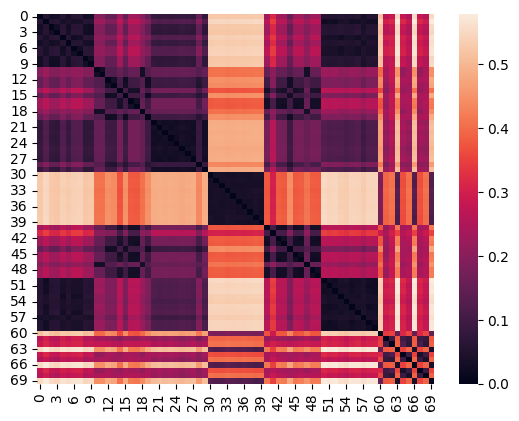

In [35]:
# order similarity matrix by model type so we might see block structure
xx = set(model_types)
fix_order_dict = {x: [] for x in set(model_types)}
for k in xx:
    if "untrained" in k:
        del fix_order_dict[k]
fix_order_dict["untrained"] = []
for i, mt in enumerate(model_types):
    if "untrained" in mt:
        fix_order_dict["untrained"].append(i)
    else:
        fix_order_dict[mt].append(i)

reindex_order = []
for _, v in fix_order_dict.items():
    reindex_order.extend(v)

pretty_order_similarities_dmd = similarities_dmd[np.ix_(reindex_order, reindex_order)]
sns.heatmap(pretty_order_similarities_dmd)

### Multidimensional Scaling (MDS) to reduce dimensions to 2D

0 multitimescale_alphas=[0.25, 0.5, 0.75, 1]
1 vanilla_alpha=0.5
2 vanilla_alpha=1
3 vanilla_alpha=0.1
4 vanilla_alpha=0.5
5 multitimescale_alpha-dist=powerlaw
6 vanilla_alpha=0.1
7 vanilla_alpha=0.5
8 multitimescale_alpha-dist=powerlaw
9 vanilla_alpha=0.1
10 multitimescale_alphas=[0.25, 0.5, 0.75, 1]
11 multitimescale_alphas=[0.25, 0.5, 0.75, 1]
12 multitimescale_alphas=[0.25, 0.75]
13 vanilla_alpha=0.5
14 vanilla_alpha=0.5
15 vanilla_alpha=0.1
16 vanilla_alpha=1
17 vanilla_alpha=1
18 vanilla_alpha=1
19 multitimescale_alphas=[0.25, 0.5, 0.75, 1]
20 multitimescale_alphas=[0.25, 0.75]
21 multitimescale_alphas=[0.25, 0.75]
22 multitimescale_alphas=[0.25, 0.75]
23 multitimescale_alphas=[0.25, 0.5, 0.75, 1]
24 multitimescale_alpha-dist=powerlaw
25 vanilla_alpha=0.1
26 multitimescale_alphas=[0.25, 0.75]
27 multitimescale_alphas=[0.25, 0.75]
28 vanilla_alpha=0.1
29 vanilla_alpha=0.5
30 vanilla_alpha=0.5
31 vanilla_alpha=0.5
32 multitimescale_alpha-dist=powerlaw
33 multitimescale_alpha-dist=p

/home/abby/.cache/pypoetry/virtualenvs/pirnns-BL3HyQ1F-py3.11/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


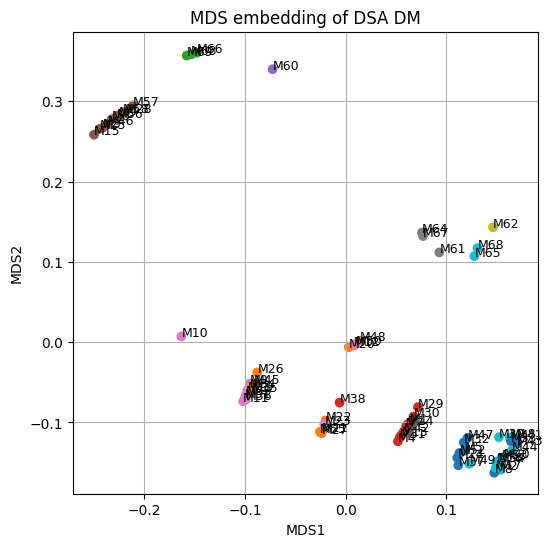

In [36]:
# get dissimilarity matrix; apparently they give us dissimilarities?
dissimilarities = similarities_dmd

# 2 components for visualisation
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=13)
embedding = mds.fit_transform(dissimilarities)

colmap = {name: n for n, name in enumerate(set(model_types))}

# print(colmap)
for i in range(len(model_types)):
    print(i, model_types[i])
plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[colmap[model_type] for model_type in model_types],
    cmap="tab10",
)

for i in range(len(embedding)):
    plt.text(embedding[i, 0], embedding[i, 1], f"M{i}", fontsize=9)

plt.title("MDS embedding of DSA DM")
plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.grid(True)
plt.show()